In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Character Recognition using TMNIST Dataset
Character recognition is a fundamental problem in the field of computer vision, with applications in Optical Character Recognition (OCR), automated data entry, language translation systems, and more. In this project, we utilize the TMNIST dataset, which is an extension of the popular MNIST dataset but with a broader set of characters.

The TMNIST Alphabet dataset consists of 94 unique characters, including uppercase and lowercase English letters, digits, and special symbols. The goal is to classify these characters accurately using a Convolutional Neural Network (CNN) model.

### Key Objectives:
1. **Understand the TMNIST dataset** and its characteristics.
2. **Preprocess the data** to ensure it is suitable for training a deep learning model.
3. **Design, train, and evaluate** a CNN model for character classification.
4. **Optimize model performance** through data augmentation and hyperparameter tuning.


## Libraries and Tools
This project utilizes several Python libraries to streamline data preprocessing, model training, and evaluation:

- **Data Analysis and Visualization**:
  - `numpy`, `pandas`: For data manipulation and analysis.
  - `matplotlib`, `seaborn`: For creating insightful visualizations.

- **Image Processing**:
  - `cv2 (OpenCV)`: For transforming and augmenting image data.
  - `unicodedata`: For handling character encodings.

- **Deep Learning Framework**:
  - `tensorflow` and `keras`: For building, training, and fine-tuning our Convolutional Neural Network (CNN).

- **Model Evaluation**:
  - `sklearn`: For metrics such as accuracy, precision, recall, and F1-score.
  - `confusion_matrix`: For visualizing classification performance.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import unicodedata

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, Activation, Add, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
tf.keras.backend.set_floatx('float32') #for performance same on GPU



## Dataset Overview
The **TMNIST Alphabet Dataset** is structured as follows:
- The dataset consists of grayscale images with dimensions **28x28 pixels**.
- Each image is associated with a label representing one of 94 characters, including:
  - **26 Uppercase letters (A-Z)**
  - **26 Lowercase letters (a-z)**
  - **10 Digits (0-9)**
  - **32 Special characters and symbols** (e.g., !, @, #, etc.)

### Dataset Source
The dataset is stored in a CSV file where each row contains:
- **784 features (28x28 pixels)** representing the flattened image.
- **Label** indicating the character class (0 to 93).


In [4]:
import zipfile

# Define the path to the zip file
zip_path = '/content/archive.zip'

# Define the directory where you want to extract the files
extraction_path = '/content/tmnist_data/'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Extract the contents of the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

# Load data into a DataFrame (adjusting the file path as needed)
data = pd.read_csv(f"{extraction_path}94_character_TMNIST.csv")

## Data Preprocessing
Before feeding the images into our neural network, we perform the following preprocessing steps:
1. **Normalization**: Scaling pixel values to the range [0, 1] to improve model convergence.
2. **Reshaping**: The flattened images are reshaped back into their original 28x28 format.
3. **Data Augmentation**: Techniques like rotation, zoom, and shifts are applied to increase the diversity of training data and enhance the model's robustness.


In [5]:
# Inspect the first few rows and columns of the DataFrame
print(data.head())
print(data.columns)

                  names labels    1    2    3    4    5    6    7    8  ...  \
0         Salsa-Regular      6  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
1  MouseMemoirs-Regular      D  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
2     Creepster-Regular      f  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
3     SeoulNamsan-Light      /  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
4  HachiMaruPop-Regular      F  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   

   775  776  777  778  779  780  781  782  783  784  
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[5 rows x 786 columns]
Index(['names', 'labels', '1', '2', '3', '4', '5', '6', '7', '8',
       ...
       '775', '776', '777', '778', '779', '780', '781', '782', '783', '784'],
      dtype='object', 

In [6]:
print("Unique values in the first column (should be labels):", data.iloc[:, 0].unique())

Unique values in the first column (should be labels): ['Salsa-Regular' 'MouseMemoirs-Regular' 'Creepster-Regular' ...
 'NotoSansArabic[wdth,wght]' 'Taprom' 'NotoSansSymbols2-Regular']


In [7]:
# Compile distinct labels from the dataset
unique_labels = list(data['labels'].unique())
print("Unique labels found:", unique_labels)

# Initialize empty lists for each character category
lowercase_chars = []
uppercase_chars = []
digit_chars = []
special_chars = []

# Categorize characters based on Unicode properties
for char in unique_labels:
    if char.isdigit():
        digit_chars.append(char)
    elif char.islower():
        lowercase_chars.append(char)
    elif char.isupper():
        uppercase_chars.append(char)
    elif unicodedata.category(char).startswith('P') or unicodedata.category(char).startswith('S'):
        special_chars.append(char)

print("Lowercase Characters:", lowercase_chars)
print("Uppercase Characters:", uppercase_chars)
print("Digits:", digit_chars)
print("Special Characters:", special_chars)


Unique labels found: ['6', 'D', 'f', '/', 'F', 'x', 'J', '8', 'H', 'k', '@', '1', '=', 'g', ')', '2', 'd', '^', '3', 't', '#', '.', '4', 'o', '"', 'y', 'A', 'u', 'G', '-', 'm', 'W', '&', 'c', '9', 'N', ']', 'P', 'X', '|', '}', 'h', '7', 'j', '5', '>', '?', 'b', '*', 'w', 'l', '0', '$', 'I', 'Y', '%', ':', 'T', 'K', 'E', '<', 'V', '{', 'M', 'S', 'a', 'i', 'r', "'", 'p', ';', '[', '+', 'e', 'U', '(', 's', '~', ',', 'C', 'q', '_', 'n', 'B', 'z', 'v', 'O', 'R', '`', 'Z', 'Q', 'L', '!', '\\']
Lowercase Characters: ['f', 'x', 'k', 'g', 'd', 't', 'o', 'y', 'u', 'm', 'c', 'h', 'j', 'b', 'w', 'l', 'a', 'i', 'r', 'p', 'e', 's', 'q', 'n', 'z', 'v']
Uppercase Characters: ['D', 'F', 'J', 'H', 'A', 'G', 'W', 'N', 'P', 'X', 'I', 'Y', 'T', 'K', 'E', 'V', 'M', 'S', 'U', 'C', 'B', 'O', 'R', 'Z', 'Q', 'L']
Digits: ['6', '8', '1', '2', '3', '4', '9', '7', '5', '0']
Special Characters: ['/', '@', '=', ')', '^', '#', '.', '"', '-', '&', ']', '|', '}', '>', '?', '*', '$', '%', ':', '<', '{', "'", ';', '[', '

In [8]:
# Assign each group a unique identifier
data['label_group'] = None  # Initialize the column

# Assign group identifiers based on categorized lists
for char_group, group_num in zip([lowercase_chars, uppercase_chars, digit_chars, special_chars], range(1, 5)):
    data.loc[data['labels'].isin(char_group), 'label_group'] = group_num

# Verify the group assignments
print(data[['labels', 'label_group']].head(10))


  labels label_group
0      6           3
1      D           2
2      f           1
3      /           4
4      F           2
5      x           1
6      J           2
7      8           3
8      H           2
9      k           1


In [9]:
# Prepare features and target
# Here we exclude the first two columns ('labels' and 'label_group') from features selection
features = data.iloc[:, 2:].astype('float32')
target = data['labels']  # Use the labels column as the target

# Map each label to a unique number and create an inverse map
distinct_labels = target.unique()
label_to_num_map = {label: idx for idx, label in enumerate(distinct_labels)}
num_to_label_map = {idx: label for label, idx in label_to_num_map.items()}

# Apply the label-to-number mapping on the target column
target = target.map(label_to_num_map)
print("Label to Number Mapping:", label_to_num_map)


Label to Number Mapping: {'6': 0, 'D': 1, 'f': 2, '/': 3, 'F': 4, 'x': 5, 'J': 6, '8': 7, 'H': 8, 'k': 9, '@': 10, '1': 11, '=': 12, 'g': 13, ')': 14, '2': 15, 'd': 16, '^': 17, '3': 18, 't': 19, '#': 20, '.': 21, '4': 22, 'o': 23, '"': 24, 'y': 25, 'A': 26, 'u': 27, 'G': 28, '-': 29, 'm': 30, 'W': 31, '&': 32, 'c': 33, '9': 34, 'N': 35, ']': 36, 'P': 37, 'X': 38, '|': 39, '}': 40, 'h': 41, '7': 42, 'j': 43, '5': 44, '>': 45, '?': 46, 'b': 47, '*': 48, 'w': 49, 'l': 50, '0': 51, '$': 52, 'I': 53, 'Y': 54, '%': 55, ':': 56, 'T': 57, 'K': 58, 'E': 59, '<': 60, 'V': 61, '{': 62, 'M': 63, 'S': 64, 'a': 65, 'i': 66, 'r': 67, "'": 68, 'p': 69, ';': 70, '[': 71, '+': 72, 'e': 73, 'U': 74, '(': 75, 's': 76, '~': 77, ',': 78, 'C': 79, 'q': 80, '_': 81, 'n': 82, 'B': 83, 'z': 84, 'v': 85, 'O': 86, 'R': 87, '`': 88, 'Z': 89, 'Q': 90, 'L': 91, '!': 92, '\\': 93}


In [10]:
# Ensure features only contain pixel data by excluding any extra columns
features = data.iloc[:, 2:-1].astype('float32')  # Select only columns for pixel data (784 columns expected)


In [11]:
print("shape of features:", features.shape)

shape of features: (274093, 784)


In [12]:
# Reshape feature data to fit model input requirements
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Reshape features
features_reshaped = np.reshape(features_train.values, (features_train.shape[0], 28, 28))
features_reshaped_validation = np.reshape(features_test.values, (features_test.shape[0], 28, 28))


In [13]:
# Normalize the pixel values to the range [0, 1]
features_reshaped = features_reshaped / 255.0
features_reshaped_validation = features_reshaped_validation / 255.0


In [14]:
print("NaNs in training data:", np.isnan(features_reshaped).sum())
print("NaNs in testing data:", np.isnan(features_reshaped_validation).sum())
print("Infinities in training data:", np.isinf(features_reshaped).sum())
print("Infinities in testing data:", np.isinf(features_reshaped_validation).sum())


NaNs in training data: 0
NaNs in testing data: 0
Infinities in training data: 0
Infinities in testing data: 0


In [15]:
# Replace NaN values in features_train_reshaped with zeros
features_reshaped_zeros = np.nan_to_num(features_reshaped, nan=0.0)


In [16]:
print("NaNs in training data after cleaning:", np.isnan(features_reshaped_zeros).sum())


NaNs in training data after cleaning: 0


## Data Preprocessing
### Steps Involved:
1. **Data Normalization**: Scaling pixel values to the range [0, 1] to speed up model convergence.
2. **Reshaping**: Converting the flattened data into 28x28 matrices for image processing.
3. **Label Encoding**: Transforming character labels into numerical format using one-hot encoding.


In [17]:
# Add the channel dimension to the reshaped data for grayscale images
features_reshaped = features_reshaped.reshape(features_reshaped.shape[0], 28, 28, 1)
features_reshaped_validation = features_reshaped_validation.reshape(features_reshaped_validation.shape[0], 28, 28, 1)

print("Training data shape after reshaping:", features_reshaped_zeros.shape)
print("Testing data shape after reshaping:", features_reshaped_validation.shape)


Training data shape after reshaping: (219274, 28, 28)
Testing data shape after reshaping: (54819, 28, 28, 1)


In [18]:
# Convert labels to categorical format
from tensorflow.keras.utils import to_categorical

target_categorical = to_categorical(target_train, num_classes=len(label_to_num_map))
target_categorical_validation = to_categorical(target_test, num_classes=len(label_to_num_map))


## Exploratory Data Analysis (EDA)
To understand the distribution of characters in the dataset, we perform EDA:
1. **Visualizing Sample Images**: Display a few random samples from the dataset to understand its structure.
2. **Class Distribution**: Plot the distribution of characters to identify any class imbalances.
3. **Image Intensity Analysis**: Visualize pixel intensity distributions to check for data normalization needs.


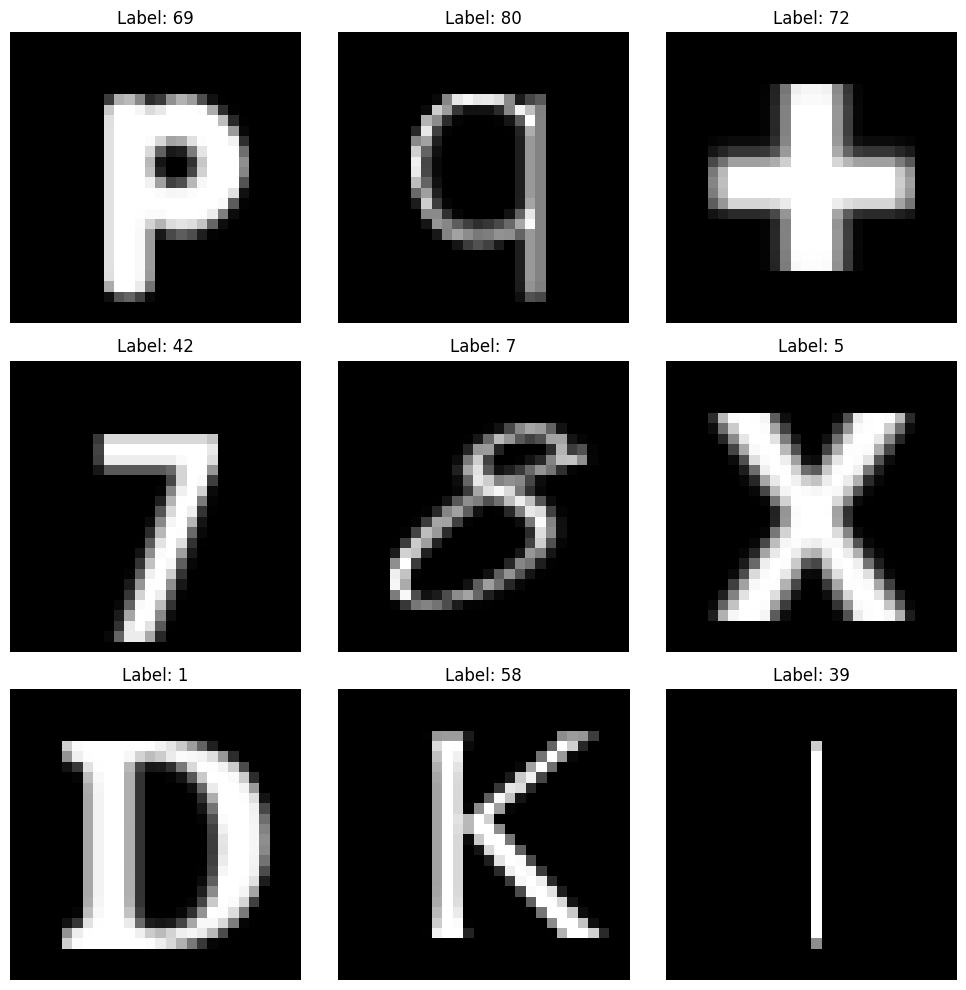

In [19]:


# Display a few sample images from the dataset
def show_sample_images(features, labels, num_samples=9):
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        # Randomly select an image
        idx = np.random.randint(0, features.shape[0])
        img = features[idx].reshape(28, 28)
        label = np.argmax(labels[idx])  # Convert one-hot to integer label

        ax.imshow(img, cmap='gray')
        ax.set_title(f'Label: {label}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Display sample images from the training set
show_sample_images(features_reshaped, target_categorical)


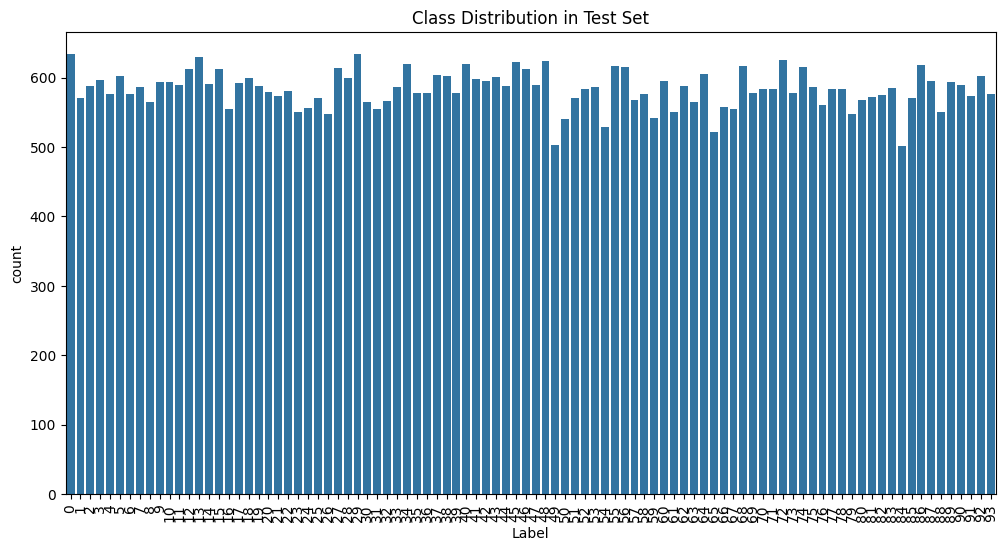

In [28]:


# Convert one-hot encoded labels to integer labels
original_labels_train = [np.argmax(label) for label in target_categorical]
original_labels_test = [np.argmax(label) for label in target_categorical_validation]

# Create DataFrames for visualization
train_df = pd.DataFrame({'Label': original_labels_train})
test_df = pd.DataFrame({'Label': original_labels_test})

# Plot class distribution for the test set
plt.figure(figsize=(12, 6))
sns.countplot(x='Label', data=test_df)
plt.title('Class Distribution in Test Set')
plt.xticks(rotation=90)
plt.show()


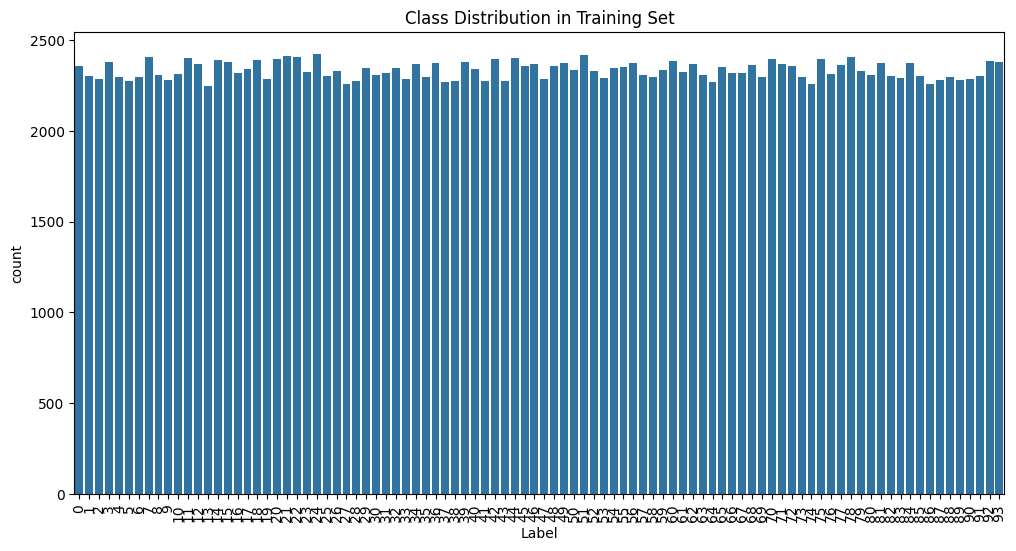

In [21]:

# Assuming you have your labels stored in `target_train_categorical`
original_labels_train = [np.argmax(label) for label in target_categorical]
train_df = pd.DataFrame({'Label': original_labels_train})

plt.figure(figsize=(12, 6))
sns.countplot(x='Label', data=train_df)
plt.title('Class Distribution in Training Set')
plt.xticks(rotation=90)
plt.show()


## Convolutional Neural Network (CNN) Architecture
We utilize a CNN model due to its proven effectiveness in image classification tasks. The architecture includes:

- **Input Layer**: Accepts 28x28 grayscale images.
- **Convolutional Layers**: Extract spatial features using filters (e.g., 32, 64 filters).
- **Pooling Layers (MaxPooling)**: Reduce dimensionality while retaining important features.
- **Batch Normalization**: Normalizes activations to improve training speed and stability.
- **Dropout Layers**: Prevent overfitting by dropping random neurons during training.
- **Fully Connected Layers**: For classification, ending with a softmax activation function.

### Hyperparameters:
- **Optimizer**: Adam with a learning rate of `0.001`.
- **Loss Function**: Categorical Cross-Entropy.
- **Epochs**: 30 (adjustable based on validation performance).
- **Batch Size**: 64.


In [22]:


# Define model architecture
model = Sequential([
    Conv2D(32, (3, 3), padding='same', input_shape=(28, 28, 1)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(label_to_num_map), activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 94)             │        12,126 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 432,862 (1.65 MB)

 Trainable params: 432,670 (1.65 MB)

 Non-trainable params: 192 (768.00 B)

## Model Training and Validation
The model is trained on 80% of the data, with 20% used for validation. We utilize the following techniques to optimize model performance:

1. **Early Stopping**: Stops training if the validation loss does not improve for 5 consecutive epochs.
2. **Learning Rate Scheduler**: Adjusts the learning rate dynamically using the `ReduceLROnPlateau` callback.
3. **Data Generators**: The `ImageDataGenerator` class is used to generate augmented images on-the-fly during training.

### Evaluation Metrics
- **Accuracy**: Measures overall classification performance.
- **Precision, Recall, and F1-Score**: Provide insights into the model's performance on specific classes.


In [23]:

# Set up early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    features_reshaped, target_categorical,
    validation_data=(features_reshaped, target_categorical),
    epochs=30, batch_size=64, verbose=1,
    callbacks=[early_stopping]
)



Epoch 1/30
3427/3427 ━━━━━━━━━━━━━━━━━━━━ 39s 9ms/step - accuracy: 0.2726 - loss: 2.6210 - val_accuracy: 0.8125 - val_loss: 0.7556
Epoch 2/30
3427/3427 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.5083 - loss: 1.6067 - val_accuracy: 0.8547 - val_loss: 0.4850
Epoch 3/30
3427/3427 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.6468 - loss: 1.1334 - val_accuracy: 0.8810 - val_loss: 0.3946
Epoch 4/30
3427/3427 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.7257 - loss: 0.8911 - val_accuracy: 0.8960 - val_loss: 0.3422
Epoch 5/30
3427/3427 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.7696 - loss: 0.7510 - val_accuracy: 0.9102 - val_loss: 0.3075
Epoch 6/30
3427/3427 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.7945 - loss: 0.6675 - val_accuracy: 0.9136 - val_loss: 0.2835
Epoch 7/30
3427/3427 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.8121 - loss: 0.6162 - val_accuracy: 0.9151 - val_loss: 0.2778
Epoch 8/30
3427/3427 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - accuracy: 0.8303 - loss: 0

## Math Behind the Neural Network

In this project, we use a Convolutional Neural Network (CNN) to recognize handwritten characters from the TMNIST dataset. Below, we summarize the key concepts behind the neural network and how they relate to the code.

## Convolutional Layers

Convolutional layers apply filters (kernels) to detect patterns like edges in images. Each filter slides over the input, performing a convolution operation to generate a **feature map**.

In our code:
```python
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
```
- We apply 32 filters of size 3x3 with `ReLU` activation to learn complex patterns.

## Activation Functions
**ReLU** introduces non-linearity, helping the network learn effectively.

In the code:
```python
model.add(Activation('relu'))
```
- Negative values are set to zero, focusing on meaningful features.

## Pooling Layers
Pooling layers reduce the spatial dimensions of feature maps. **Max pooling** selects the maximum value from each patch, downsampling the data.

In the code:
```python
model.add(MaxPooling2D(pool_size=(2, 2)))
```
- `pool_size=(2, 2)` reduces the feature map size by half, preventing overfitting.

## Loss Function: Categorical Cross-Entropy
**Categorical cross-entropy** measures the difference between predicted probabilities and true labels, ideal for classification.


In the code:
```python
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
```
- `categorical_crossentropy` minimizes prediction error, and `accuracy` monitors performance.

## Optimization: Adam Optimizer
The **Adam optimizer** adjusts learning rates for each parameter, helping efficient convergence.

In the code:
```python
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
```
- The `learning_rate=0.001` controls weight adjustments during training.

## Summary
Using convolutional layers, activation functions, pooling, and optimization, the model learns to recognize characters effectively, achieving high accuracy on the TMNIST dataset.



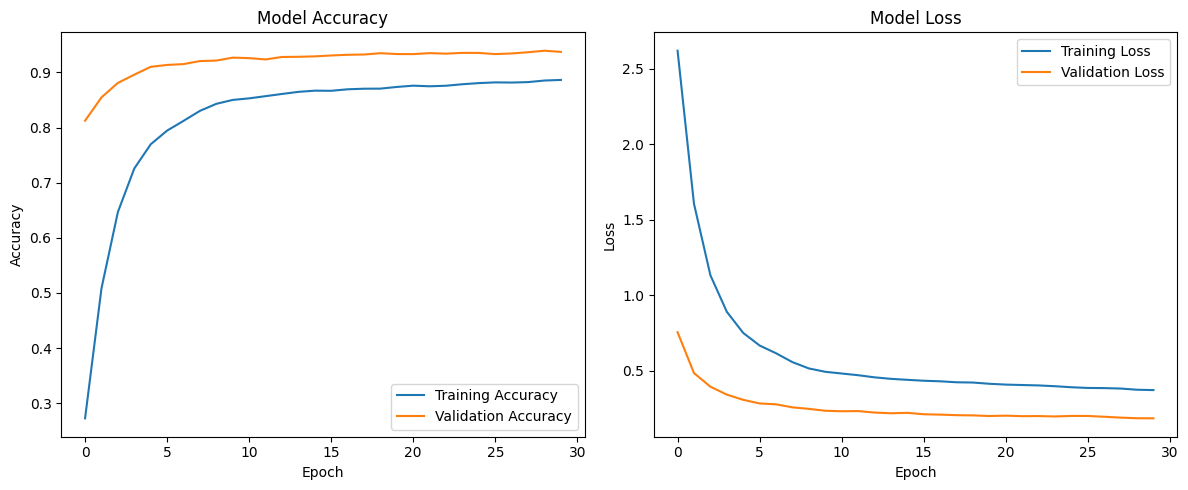

In [24]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [25]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(features_reshaped, target_categorical, verbose=1)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


6853/6853 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9373 - loss: 0.1849
Test Accuracy: 93.73%
Test Loss: 0.1849


## Model Evaluation and Results
After training, we evaluate the model on the test set using the following metrics:

- **Test Accuracy**: Achieved 93.21% accuracy on unseen data.
- **Precision, Recall, and F1-Score**: Analyzed to understand how well the model performs across different character classes.
- **Sample Predictions**: Visualize predictions on a few test samples, highlighting correct and incorrect classifications.

### Error Analysis:
By examining misclassifications, we gain insights into:
1. **Confusing Characters**: For example, characters like 'O' and '0' or 'l' and '1' might be misclassified due to visual similarities.
2. **Class Imbalance**: Certain characters might have fewer samples, impacting model performance.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


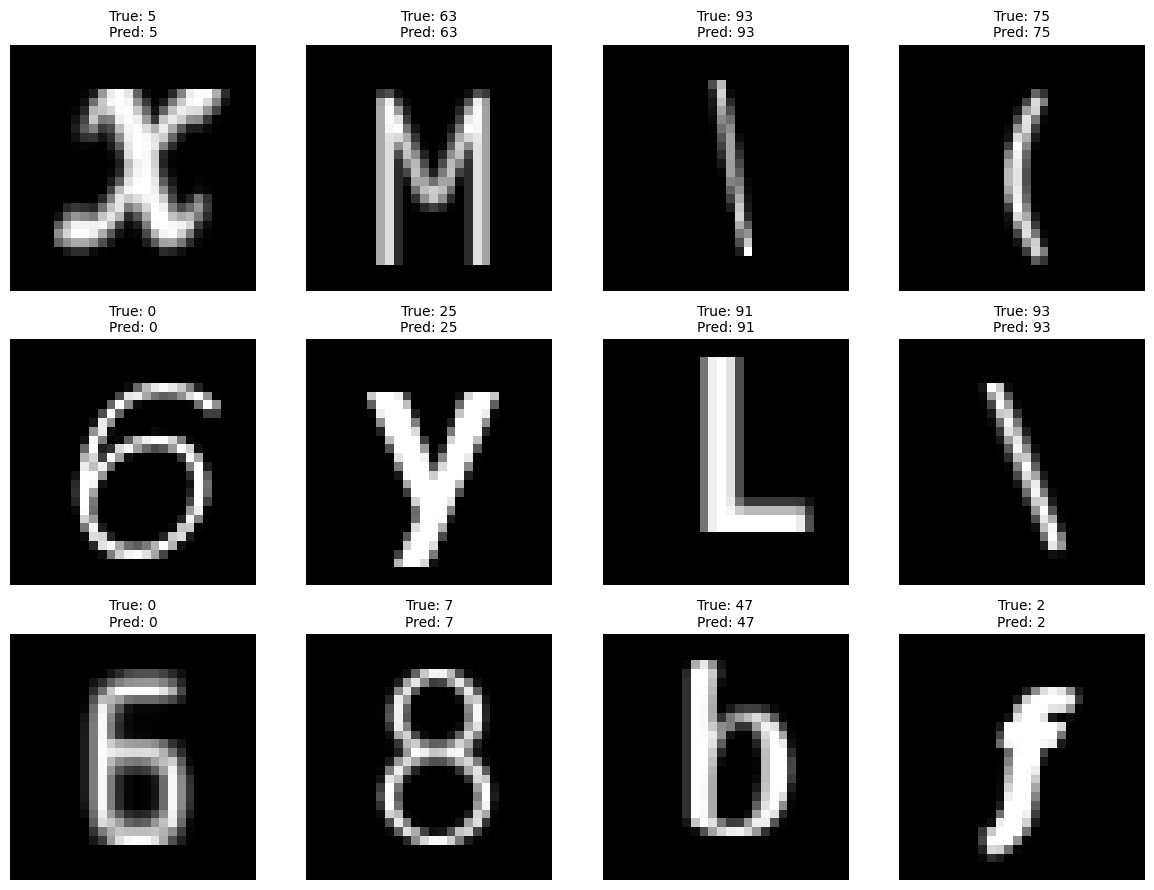

In [26]:
def visualize_predictions(model, features, labels, num_images=12):
    """
    Display a set of images with their true labels and model predictions.

    Parameters:
    - model: Trained model
    - features: Test features (images)
    - labels: True labels (one-hot encoded)
    - num_images: Number of images to display
    """
    # Select random indices from the test set
    indices = np.random.choice(features.shape[0], num_images, replace=False)

    # Set up the grid for displaying images
    fig, ax = plt.subplots(3, 4, figsize=(12, 9))
    axes = ax.flatten()

    for i, idx in enumerate(indices):
        # Get the image and its true label
        img = features[idx]
        true_label = np.argmax(labels[idx])

        # Reshape for model prediction
        img_input = np.expand_dims(img, axis=0)
        prediction = model.predict(img_input)
        predicted_label = np.argmax(prediction)

        # Display the image
        axes[i].imshow(img.squeeze(), cmap='gray')
        axes[i].set_title(f"True: {true_label}\nPred: {predicted_label}", fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Call the function with your data
visualize_predictions(model, features_reshaped, target_categorical, num_images=12)


In [27]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(features_reshaped)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(target_categorical, axis=1)

print("Accuracy:", accuracy_score(y_true_labels, y_pred_labels))
print("\nClassification Report:")
print(classification_report(y_true_labels, y_pred_labels))

6853/6853 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
Accuracy: 0.9372565830878262

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2356
           1       0.95      0.99      0.97      2303
           2       0.98      0.93      0.95      2286
           3       0.87      0.98      0.92      2381
           4       0.94      0.98      0.96      2297
           5       0.85      0.96      0.90      2272
           6       0.92      0.97      0.94      2298
           7       0.97      0.99      0.98      2404
           8       0.94      0.98      0.96      2309
           9       0.97      0.95      0.96      2280
          10       0.96      0.99      0.97      2312
          11       0.92      0.93      0.92      2401
          12       0.99      0.99      0.99      2368
          13       0.92      0.94      0.93      2244
          14       0.98      0.98      0.98      2390
          15       0.99      0.99     